<a href="https://colab.research.google.com/github/kananshr13/CSET-343-Ai-in-Healthcare/blob/main/Lab_Experiment_5_CSET_343.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score)

sns.set_style("whitegrid")

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/dermatology/dermatology.data"

cols = ["erythema","scaling","definite_borders","itching","koebner_phenomenon",
        "polygonal_papules","follicular_papules","oral_mucosal_involvement",
        "knee_elbow_involvement","scalp_involvement","family_history",
        "melanin_incontinence","eosinophils_infiltrate","PNL_infiltrate",
        "fibrosis_papillary_dermis","exocytosis","acanthosis","hyperkeratosis",
        "parakeratosis","clubbing_rete_ridges","elongation_rete_ridges",
        "thinning_suprapapillary_epidermis","spongiform_pustule","munro_microabcess",
        "focal_hypergranulosis","disappearance_granular_layer",
        "vacuolisation_damage_basal_layer","spongiosis","saw_tooth_appearance_retes",
        "follicular_horn_plug","perifollicular_parakeratosis",
        "inflammatory_monoluclear_inflitrate","band_like_infiltrate","age","Class"]

df = pd.read_csv(url, header=None, names=cols, na_values="?")
print(df.shape)
df.head()

(366, 35)


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band_like_infiltrate,age,Class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55.0,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8.0,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26.0,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40.0,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45.0,3


In [3]:
df.info()
df.describe().T   # count, mean, std, min, quartiles (50% = median), max

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   erythema                             366 non-null    int64  
 1   scaling                              366 non-null    int64  
 2   definite_borders                     366 non-null    int64  
 3   itching                              366 non-null    int64  
 4   koebner_phenomenon                   366 non-null    int64  
 5   polygonal_papules                    366 non-null    int64  
 6   follicular_papules                   366 non-null    int64  
 7   oral_mucosal_involvement             366 non-null    int64  
 8   knee_elbow_involvement               366 non-null    int64  
 9   scalp_involvement                    366 non-null    int64  
 10  family_history                       366 non-null    int64  
 11  melanin_incontinence            

,count,mean,std,min,25%,50%,75%,max
erythema,366.0,2.068306,0.664753,0.0,2.0,2.0,2.00,3.0
scaling,366.0,1.795082,0.701527,0.0,1.0,2.0,2.00,3.0
definite_borders,366.0,1.549180,0.907525,0.0,1.0,2.0,2.00,3.0
itching,366.0,1.366120,1.138299,0.0,0.0,1.0,2.00,3.0
koebner_phenomenon,366.0,0.633880,0.908016,0.0,0.0,0.0,1.00,3.0
polygonal_papules,366.0,0.448087,0.957327,0.0,0.0,0.0,0.00,3.0
follicular_papules,366.0,0.166667,0.570588,0.0,0.0,0.0,0.00,3.0
oral_mucosal_involvement,366.0,0.377049,0.834147,0.0,0.0,0.0,0.00,3.0
knee_elbow_involvement,366.0,0.614754,0.982979,0.0,0.0,0.0,1.00,3.0
scalp_involvement,366.0,0.519126,0.905639,0.0,0.0,0.0,1.00,3.0


In [4]:
# Add median explicitly
summary = df.describe().T
summary["median"] = df.median()
summary[["mean","median","std","min","max"]]

,mean,median,std,min,max
erythema,2.068306,2.0,0.664753,0.0,3.0
scaling,1.795082,2.0,0.701527,0.0,3.0
definite_borders,1.549180,2.0,0.907525,0.0,3.0
itching,1.366120,1.0,1.138299,0.0,3.0
koebner_phenomenon,0.633880,0.0,0.908016,0.0,3.0
polygonal_papules,0.448087,0.0,0.957327,0.0,3.0
follicular_papules,0.166667,0.0,0.570588,0.0,3.0
oral_mucosal_involvement,0.377049,0.0,0.834147,0.0,3.0
knee_elbow_involvement,0.614754,0.0,0.982979,0.0,3.0
scalp_involvement,0.519126,0.0,0.905639,0.0,3.0


In [5]:
# Missing values
print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])

# Duplicates
print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

# Outliers (IQR method). Most features are ordinal 0-3, so this is only meaningful for 'age'
Q1, Q3 = df["age"].quantile([0.25, 0.75])
IQR = Q3 - Q1
low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = df[(df["age"] < low) | (df["age"] > high)]
print(f"\nAge outliers (outside [{low:.1f}, {high:.1f}]): {len(outliers)}")

Missing values:
 age    8
dtype: int64

Duplicate rows: 0

Age outliers (outside [-12.1, 86.9]): 0


In [6]:
# Handle: 'age' has missing values -> impute with median (robust to outliers).
# Age values are genuine (0-75), so we keep the outliers rather than remove real patients.
df["age"] = df["age"].fillna(df["age"].median())
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


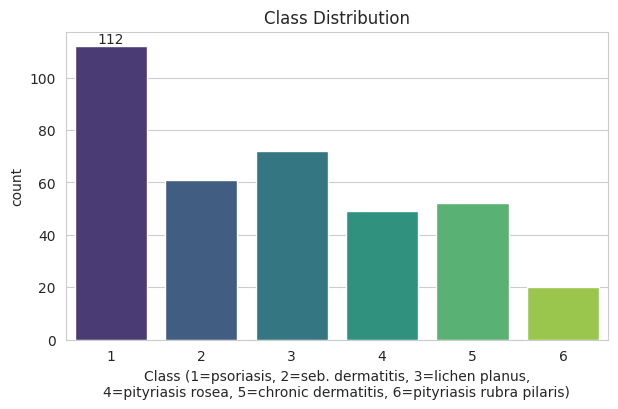

Class
1    30.60
2    16.67
3    19.67
4    13.39
5    14.21
6     5.46
Name: proportion, dtype: float64


In [7]:
# 5a. Class distribution
plt.figure(figsize=(7,4))
ax = sns.countplot(x="Class", data=df, palette="viridis")
ax.bar_label(ax.containers[0])
plt.title("Class Distribution")
plt.xlabel("Class (1=psoriasis, 2=seb. dermatitis, 3=lichen planus,\n4=pityriasis rosea, 5=chronic dermatitis, 6=pityriasis rubra pilaris)")
plt.show()

print((df["Class"].value_counts(normalize=True).sort_index()*100).round(2))

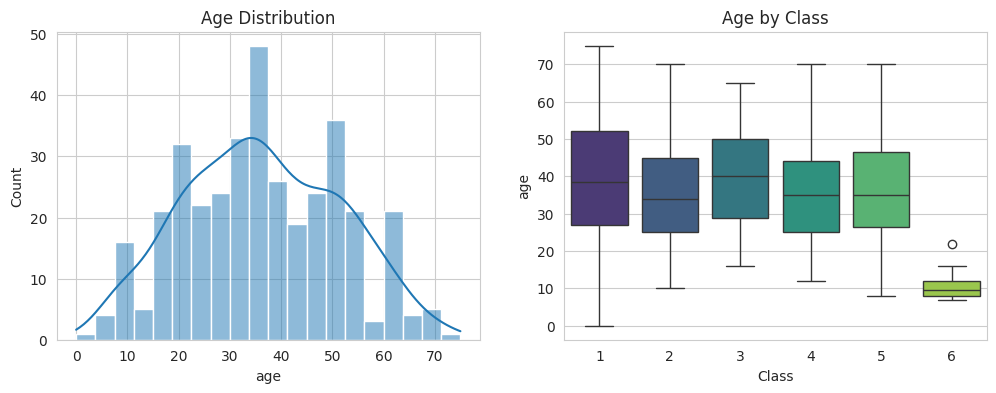

In [8]:
# 5b. Histogram + boxplot for age
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df["age"], bins=20, kde=True, ax=ax[0])
ax[0].set_title("Age Distribution")
sns.boxplot(x="Class", y="age", data=df, ax=ax[1], palette="viridis")
ax[1].set_title("Age by Class")
plt.show()

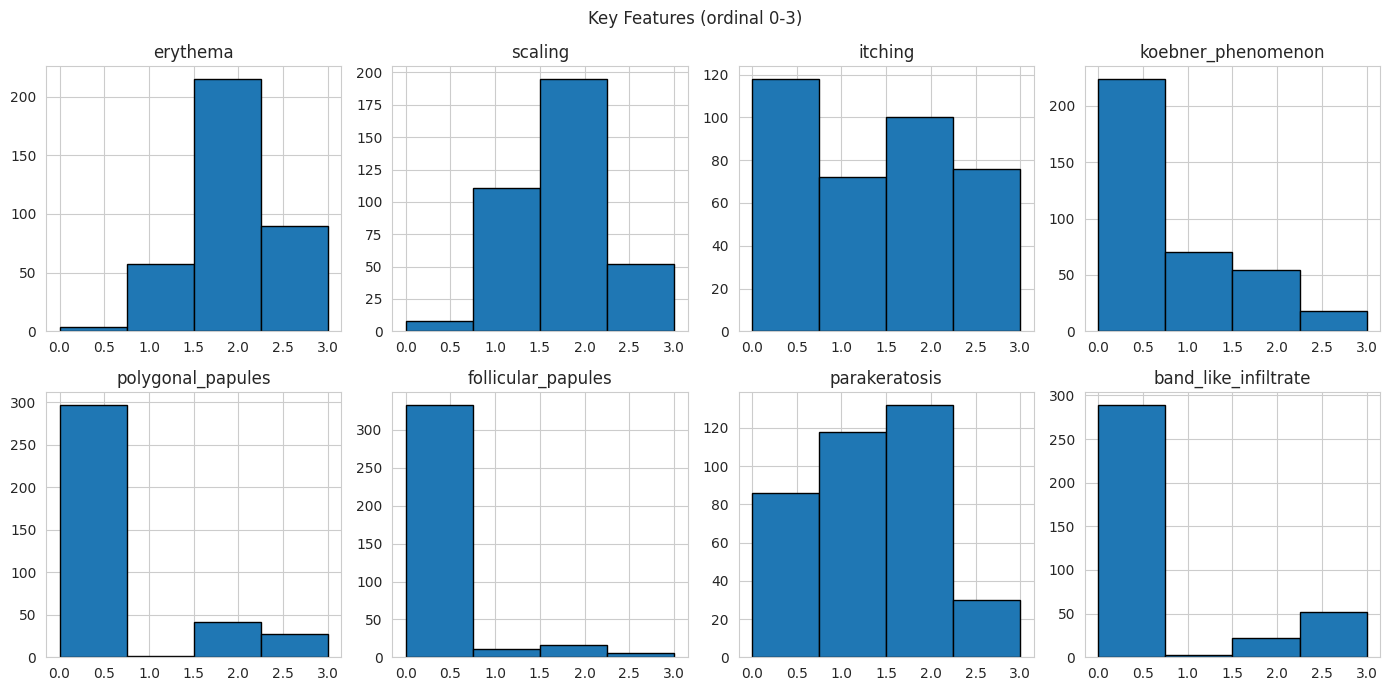

In [9]:
# 5c. Histograms of a few key clinical/histopathological features
key_feats = ["erythema","scaling","itching","koebner_phenomenon",
             "polygonal_papules","follicular_papules","parakeratosis","band_like_infiltrate"]
df[key_feats].hist(figsize=(14,7), bins=4, layout=(2,4), edgecolor="black")
plt.suptitle("Key Features (ordinal 0-3)")
plt.tight_layout()
plt.show()

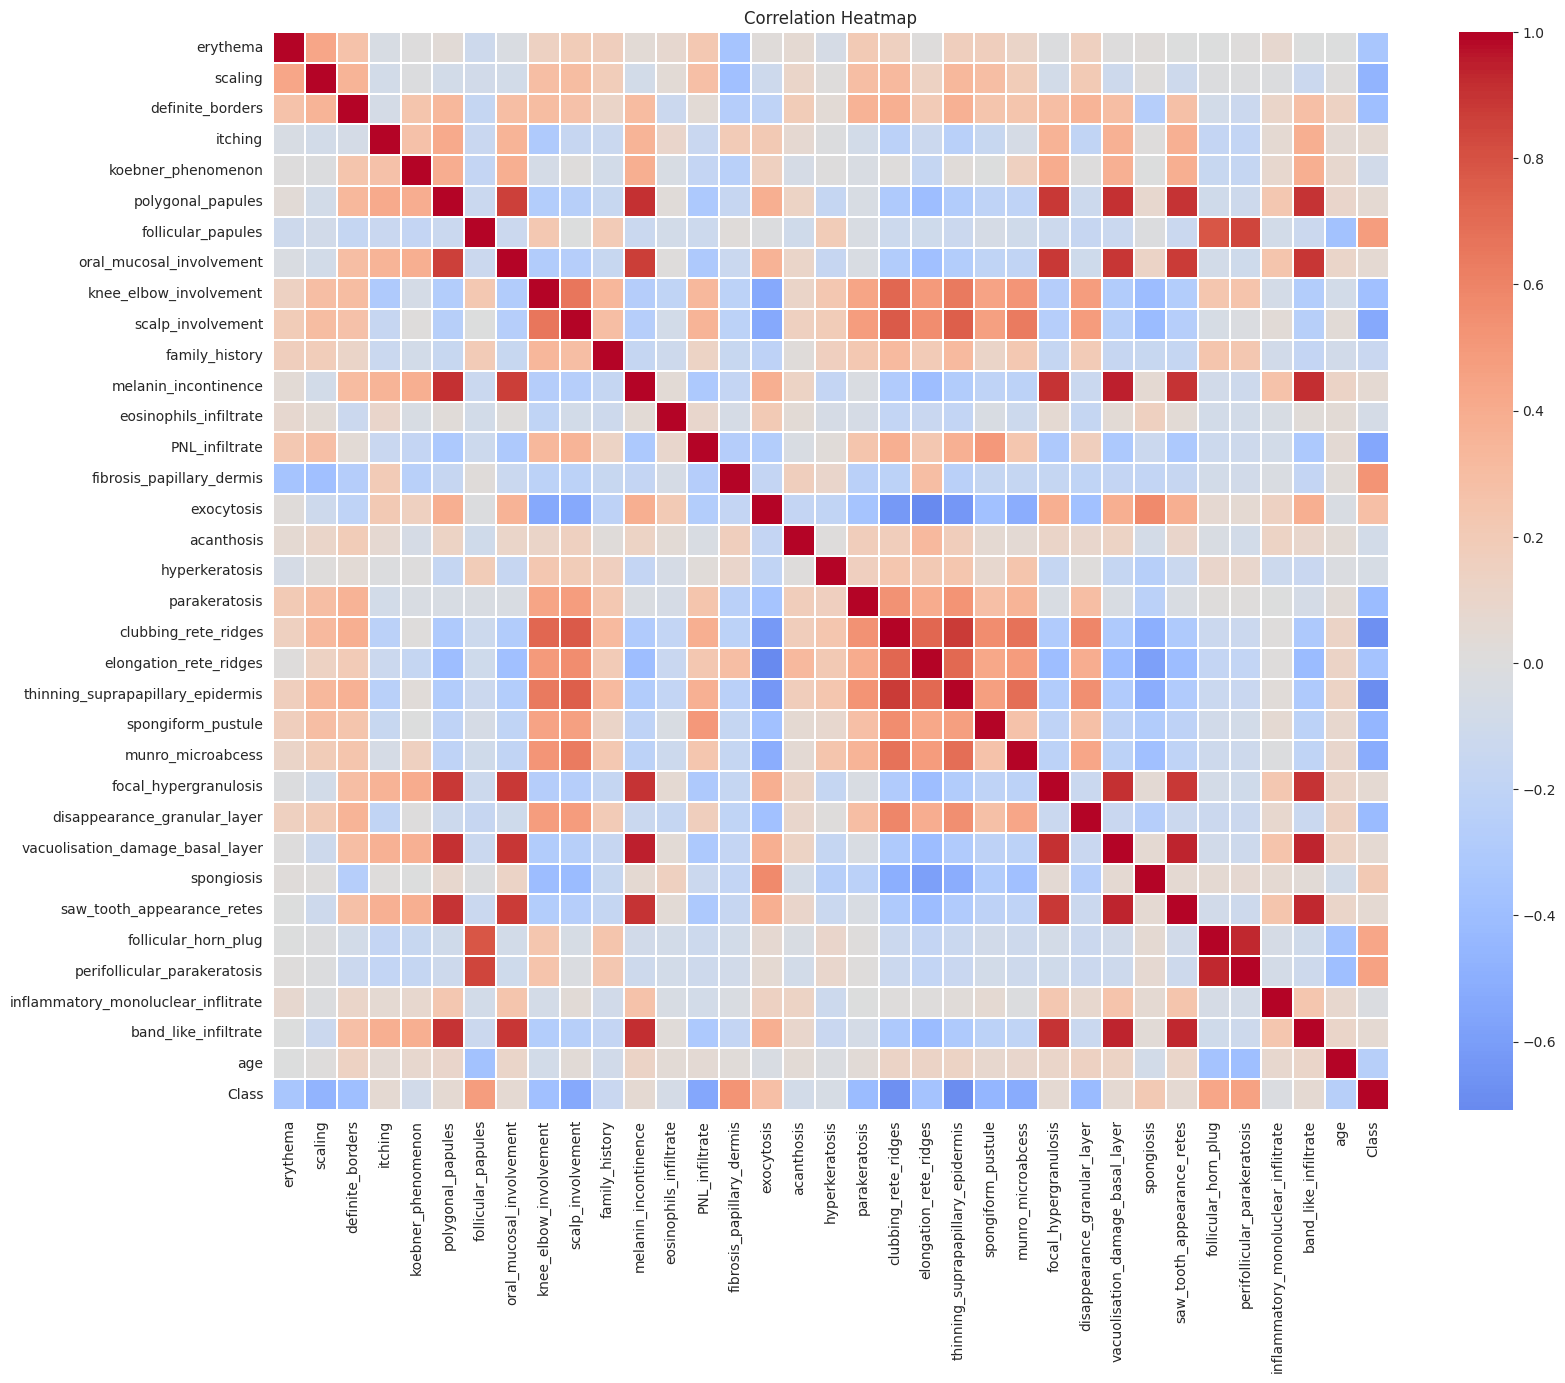

,Class
thinning_suprapapillary_epidermis,0.684864
clubbing_rete_ridges,0.668781
PNL_infiltrate,0.550195
scalp_involvement,0.533208
fibrosis_papillary_dermis,0.526976
munro_microabcess,0.520995
follicular_papules,0.477813
scaling,0.468688
perifollicular_parakeratosis,0.457025
spongiform_pustule,0.449407


In [10]:
# 5d. Correlation heatmap
plt.figure(figsize=(18,14))
sns.heatmap(df.corr(), cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Correlation Heatmap")
plt.show()

# Features most correlated with the target
df.corr()["Class"].drop("Class").abs().sort_values(ascending=False).head(10)

In [12]:
X = df.drop("Class", axis=1)
y_raw = df["Class"]

le = LabelEncoder()
y = le.fit_transform(y_raw)          # 1..6 -> 0..5
class_names = ["Psoriasis","Seb. dermatitis","Lichen planus",
               "Pityriasis rosea","Chronic dermatitis","P. rubra pilaris"]
print(dict(zip(le.classes_, le.transform(le.classes_))))

{np.int64(1): np.int64(0), np.int64(2): np.int64(1), np.int64(3): np.int64(2), np.int64(4): np.int64(3), np.int64(5): np.int64(4), np.int64(6): np.int64(5)}


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("\nTrain class %:\n", pd.Series(y_train).value_counts(normalize=True).sort_index().round(3))
print("\nTest class %:\n", pd.Series(y_test).value_counts(normalize=True).sort_index().round(3))

Train: (292, 34)  Test: (74, 34)

Train class %:
 0    0.305
1    0.168
2    0.195
3    0.134
4    0.144
5    0.055
Name: proportion, dtype: float64

Test class %:
 0    0.311
1    0.162
2    0.203
3    0.135
4    0.135
5    0.054
Name: proportion, dtype: float64


In [14]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN":                 KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF)":           SVC(kernel="rbf", probability=True, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
    "Gaussian NB":         GaussianNB(),
}

preds, probas = {}, {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds[name]  = model.predict(X_test_s)
    probas[name] = model.predict_proba(X_test_s)
    print(f"{name} trained.")

Logistic Regression trained.
KNN trained.
SVM (RBF) trained.
Random Forest trained.
Gaussian NB trained.


In [16]:
rows = []
for name in models:
    rows.append({
        "Model": name,
        "Accuracy":        accuracy_score(y_test, preds[name]),
        "Precision (macro)": precision_score(y_test, preds[name], average="macro"),
        "Recall (macro)":    recall_score(y_test, preds[name], average="macro"),
        "F1 (macro)":        f1_score(y_test, preds[name], average="macro"),
        "F1 (weighted)":     f1_score(y_test, preds[name], average="weighted"),
    })
results = pd.DataFrame(rows).set_index("Model").round(4)
results.sort_values("F1 (macro)", ascending=False)

,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
Model,,,,,
SVM (RBF),0.9730,0.9722,0.9722,0.9697,0.9730
Logistic Regression,0.9595,0.9615,0.9611,0.9574,0.9606
Random Forest,0.9595,0.9545,0.9556,0.9545,0.9595
KNN,0.9054,0.9071,0.9094,0.9034,0.9081
Gaussian NB,0.8649,0.8813,0.8583,0.8224,0.8450


In [17]:
for name in models:
    print("="*60, f"\n{name}\n", "="*60)
    print(classification_report(y_test, preds[name], target_names=class_names, digits=3))

Logistic Regression
                    precision    recall  f1-score   support

         Psoriasis      1.000     1.000     1.000        23
   Seb. dermatitis      1.000     0.833     0.909        12
     Lichen planus      1.000     0.933     0.966        15
  Pityriasis rosea      0.769     1.000     0.870        10
Chronic dermatitis      1.000     1.000     1.000        10
  P. rubra pilaris      1.000     1.000     1.000         4

          accuracy                          0.959        74
         macro avg      0.962     0.961     0.957        74
      weighted avg      0.969     0.959     0.961        74

KNN
                    precision    recall  f1-score   support

         Psoriasis      1.000     0.957     0.978        23
   Seb. dermatitis      0.800     0.667     0.727        12
     Lichen planus      1.000     0.933     0.966        15
  Pityriasis rosea      0.643     0.900     0.750        10
Chronic dermatitis      1.000     1.000     1.000        10
  P. rubra p

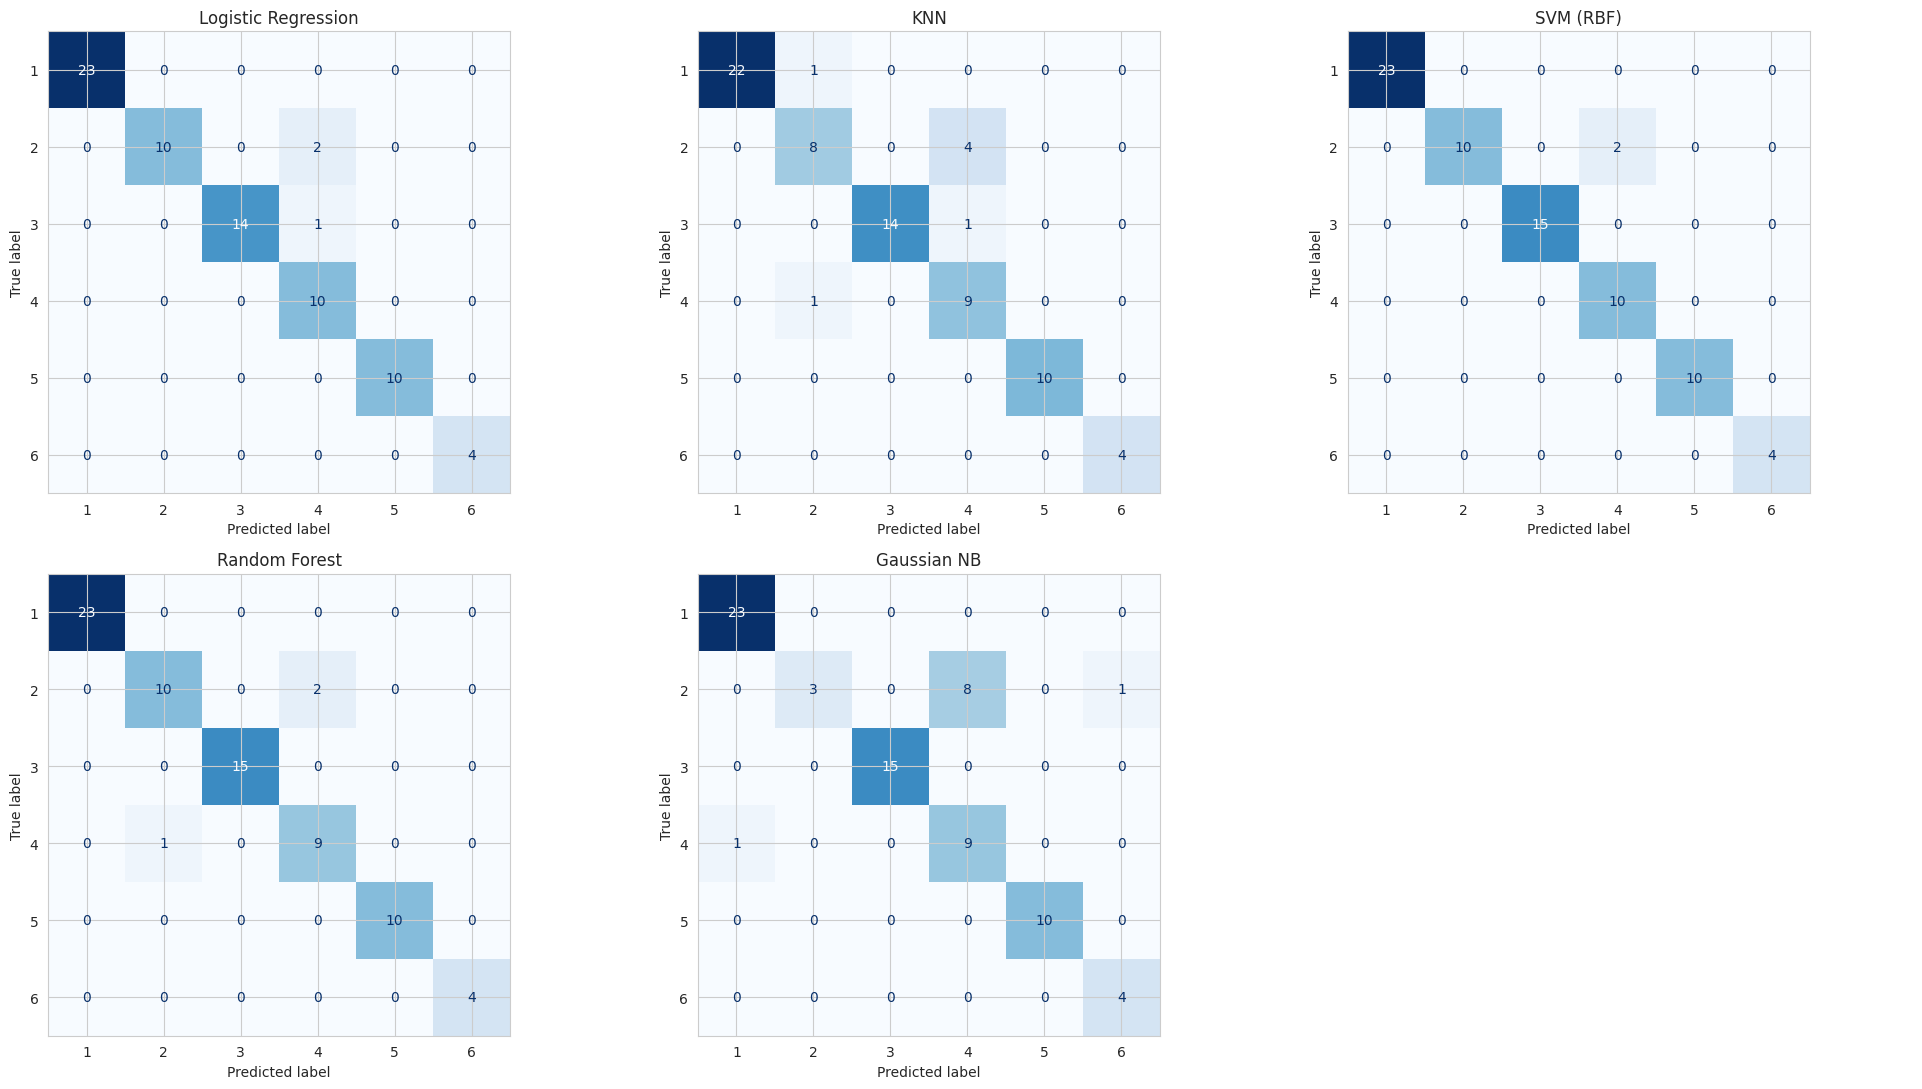

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.ravel()
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, preds[name])
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

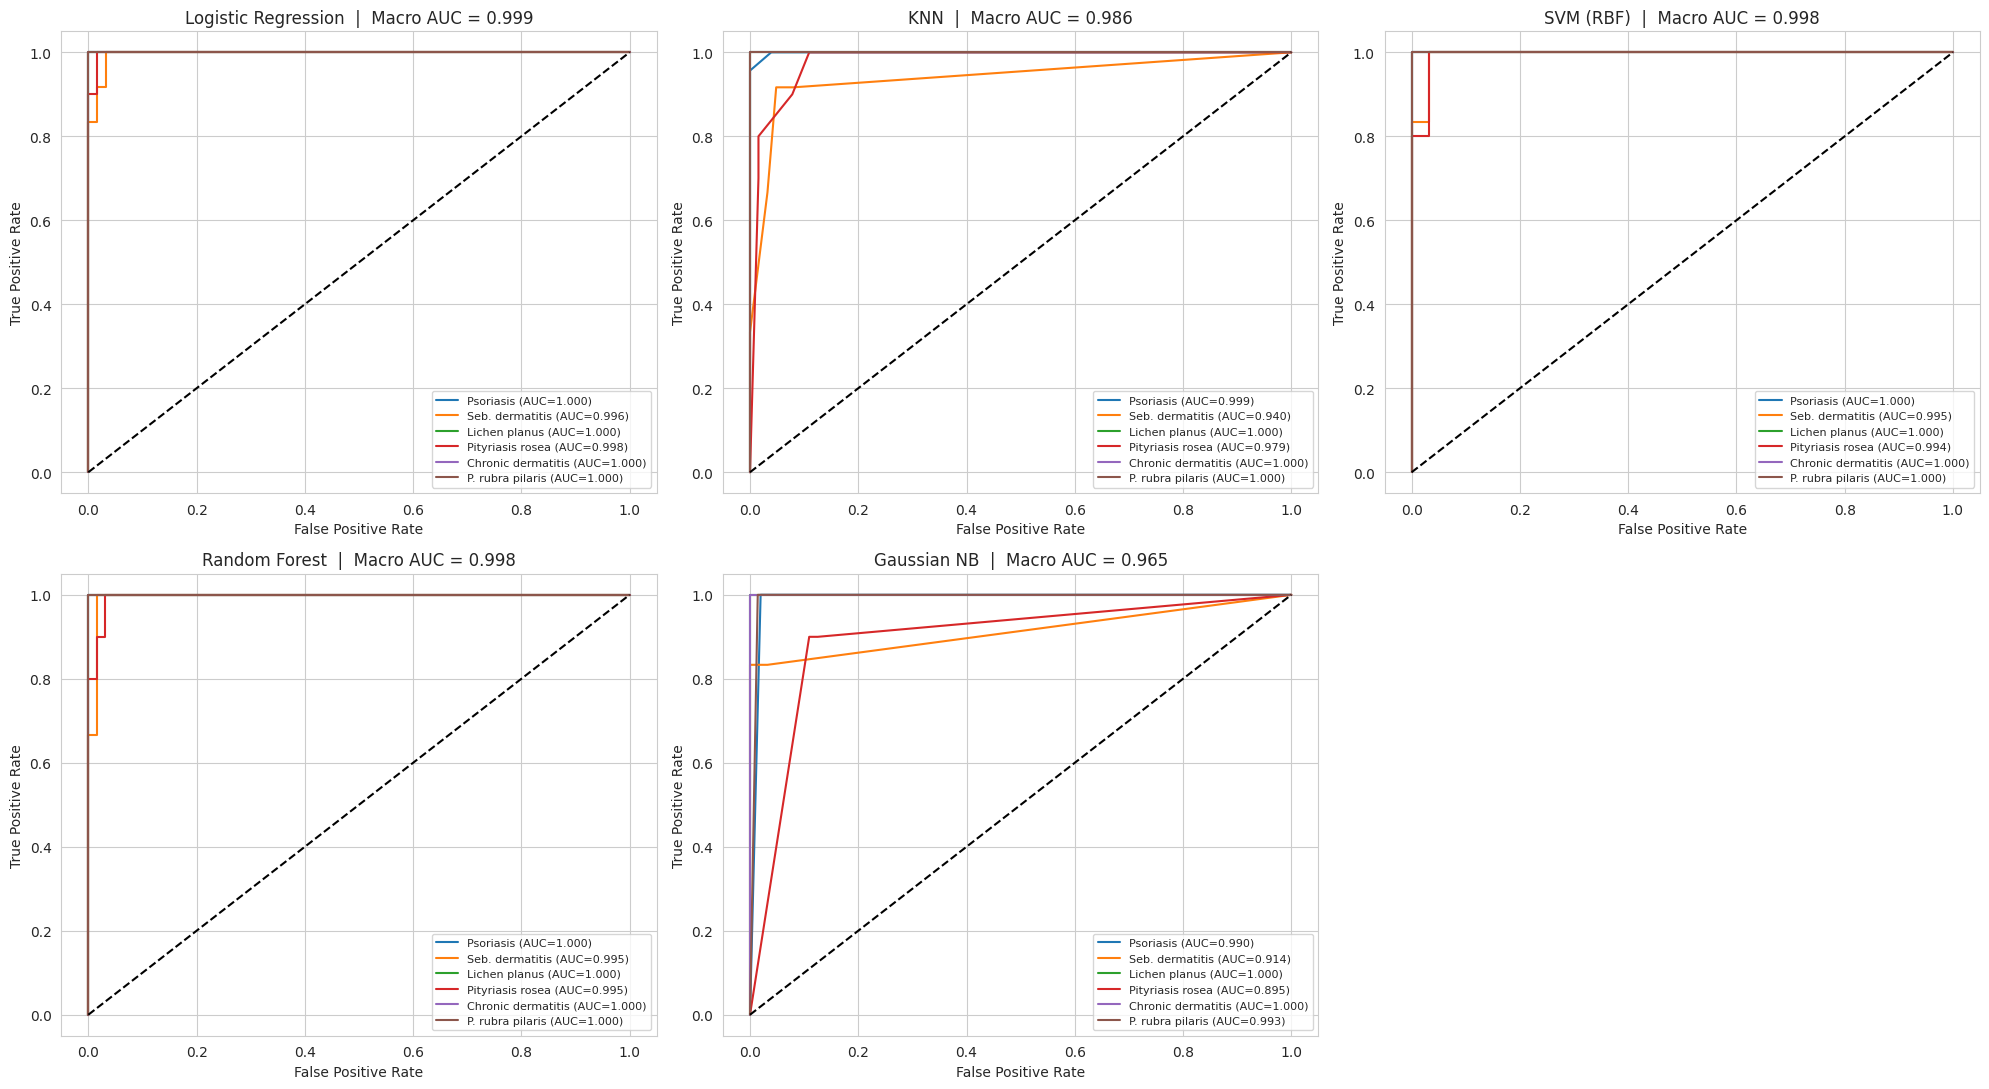

,Macro OvR AUC
Logistic Regression,0.9991
KNN,0.9863
SVM (RBF),0.9981
Random Forest,0.9983
Gaussian NB,0.9653


In [19]:
y_test_bin = label_binarize(y_test, classes=range(6))

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.ravel()
auc_table = {}

for ax, name in zip(axes, models):
    for i in range(6):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probas[name][:, i])
        ax.plot(fpr, tpr, label=f"{class_names[i]} (AUC={auc(fpr, tpr):.3f})")
    ax.plot([0,1],[0,1],"k--")
    macro_auc = roc_auc_score(y_test, probas[name], multi_class="ovr", average="macro")
    auc_table[name] = macro_auc
    ax.set_title(f"{name}  |  Macro AUC = {macro_auc:.3f}")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8, loc="lower right")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

pd.Series(auc_table, name="Macro OvR AUC").round(4)

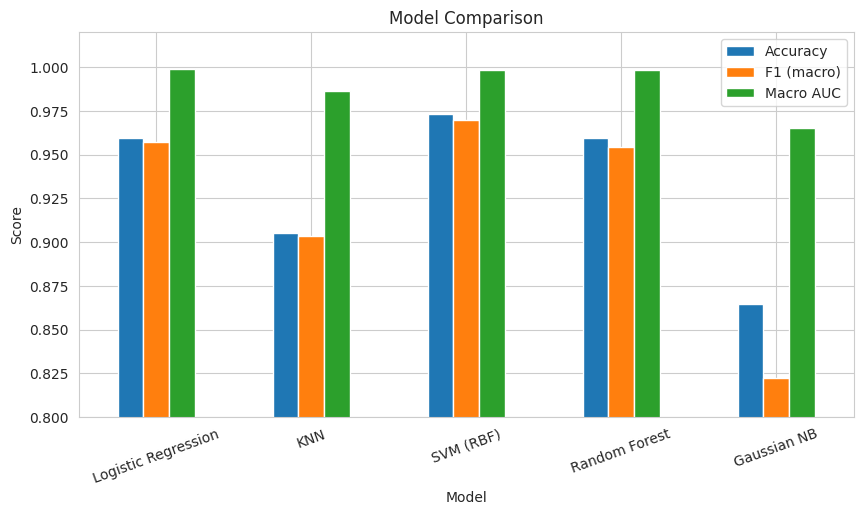

,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),Macro AUC
Model,,,,,,
Logistic Regression,0.9595,0.9615,0.9611,0.9574,0.9606,0.999068
KNN,0.9054,0.9071,0.9094,0.9034,0.9081,0.986262
SVM (RBF),0.9730,0.9722,0.9722,0.9697,0.9730,0.998062
Random Forest,0.9595,0.9545,0.9556,0.9545,0.9595,0.998323
Gaussian NB,0.8649,0.8813,0.8583,0.8224,0.8450,0.965260


In [20]:
results["Macro AUC"] = pd.Series(auc_table)
results[["Accuracy","F1 (macro)","Macro AUC"]].plot(kind="bar", figsize=(10,5), ylim=(0.8,1.02))
plt.title("Model Comparison")
plt.xticks(rotation=20)
plt.ylabel("Score")
plt.show()
results

In [21]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
skf = StratifiedKFold(5, shuffle=True, random_state=42)
Xs = scaler.fit_transform(X)
for name, m in models.items():
    s = cross_val_score(m, Xs, y, cv=skf, scoring="f1_macro")
    print(f"{name}: {s.mean():.3f} ± {s.std():.3f}")

Logistic Regression: 0.966 ± 0.018
KNN: 0.960 ± 0.022
SVM (RBF): 0.970 ± 0.018
Random Forest: 0.976 ± 0.011
Gaussian NB: 0.828 ± 0.043


### Interpretation of Results

1. **Overall performance:** All models should score high (typically 95%+ accuracy) because
   the dermatology features are clinically informative and well separated across classes.
   Best model: **<name>** (Accuracy = __, Macro-F1 = __, Macro-AUC = __).

2. **Accuracy vs macro-F1:** Because of class imbalance, I focused on macro-F1, which weights
   every class equally. A gap between accuracy and macro-F1 would show weak minority-class performance.

3. **Confusion matrix:** Errors, if any, occur between clinically similar diseases
   (e.g., seboreic dermatitis vs psoriasis, or chronic dermatitis vs lichen planus),
   which share overlapping symptoms. Class 6 has only ~4 test samples, so a single
   mistake changes its recall by 25%.

4. **ROC/AUC:** AUC close to 1.0 means the models rank the correct class highly even when
   the hard label is wrong, so the probability outputs are reliable.

5. **Model comparison:** Linear models (LR, SVM) do well because the data is nearly linearly
   separable after scaling. Random Forest is robust and handles ordinal features naturally.
   KNN is sensitive to scaling/k. Naive Bayes assumes feature independence, which is violated
   here (many correlated histopathological features), so it may lag slightly.

6. **Limitations:** The test set is small (~72 samples), so results vary by split. Using
   stratified 5-fold cross-validation would give a more stable estimate.